## 0. Imports

In [6]:
!pip install codecarbon

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.preprocessing import LabelEncoder

import shap

# CodeCarbon is used for Frugal AI (carbon footprint tracking)
try:
    from codecarbon import EmissionsTracker
    CODECARBON_AVAILABLE = True
except ImportError:
    CODECARBON_AVAILABLE = False
    print("CodeCarbon not installed. Run: pip install codecarbon")

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

## 1. Cybersecurity : GDPR Anonymization

HR data contains personal information. Before doing anything, we need to:
- Remove direct identifiers (names, IDs, emails)
- Isolate sensitive attributes (gender, ethnicity), we will use them later for the bias audit, but not for training
- Remove columns that would cause data leakage (e.g. the termination date only exists for people who already left)

This is required by GDPR. Under the EU AI Act, an HR prediction model is also considered high-risk, so transparency and data protection are mandatory.

In [10]:
# Load the dataset
df = pd.read_csv('HRDataset_v14.csv')
print(f'Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')

# Columns that directly identify a person -> remove for GDPR
direct_identifiers = ['Employee_Name', 'EmpID', 'ManagerName']

# Columns that would leak the answer
leakage_cols = ['DateofTermination', 'TermReason', 'EmploymentStatus', 'EmpStatusID']

# Sensitive attributes: kept separately for the bias audit, but not used in training
sensitive_cols = ['Sex', 'RaceDesc', 'MaritalDesc','GenderID']
sensitive_data = df[sensitive_cols].copy()

# Remove everything from the training dataframe
cols_to_remove = direct_identifiers + leakage_cols + sensitive_cols
df_clean = df.drop(columns=cols_to_remove)

print(f'After anonymization: {df_clean.shape[1]} columns remaining')
print('Sensitive attributes saved separately for the ethics audit.')

Dataset loaded: 311 rows, 36 columns
After anonymization: 25 columns remaining
Sensitive attributes saved separately for the ethics audit.


## 2. HR Data Exploration

Before building a model, we explore the data to understand why employees leave and which departments are most affected.

First 5 rows of the cleaned DataFrame:
   MarriedID  MaritalStatusID  DeptID  PerfScoreID  FromDiversityJobFairID  \
0          0                0       5            4                       0   
1          1                1       3            3                       0   
2          1                1       5            3                       0   
3          1                1       5            3                       0   
4          0                2       5            3                       0   

   Salary  Termd  PositionID                  Position State  ...  \
0   62506      0          19   Production Technician I    MA  ...   
1  104437      1          27                   Sr. DBA    MA  ...   
2   64955      1          20  Production Technician II    MA  ...   
3   64991      0          19   Production Technician I    MA  ...   
4   50825      1          19   Production Technician I    MA  ...   

          Department ManagerID RecruitmentSource PerformanceScore  \
0  Produ

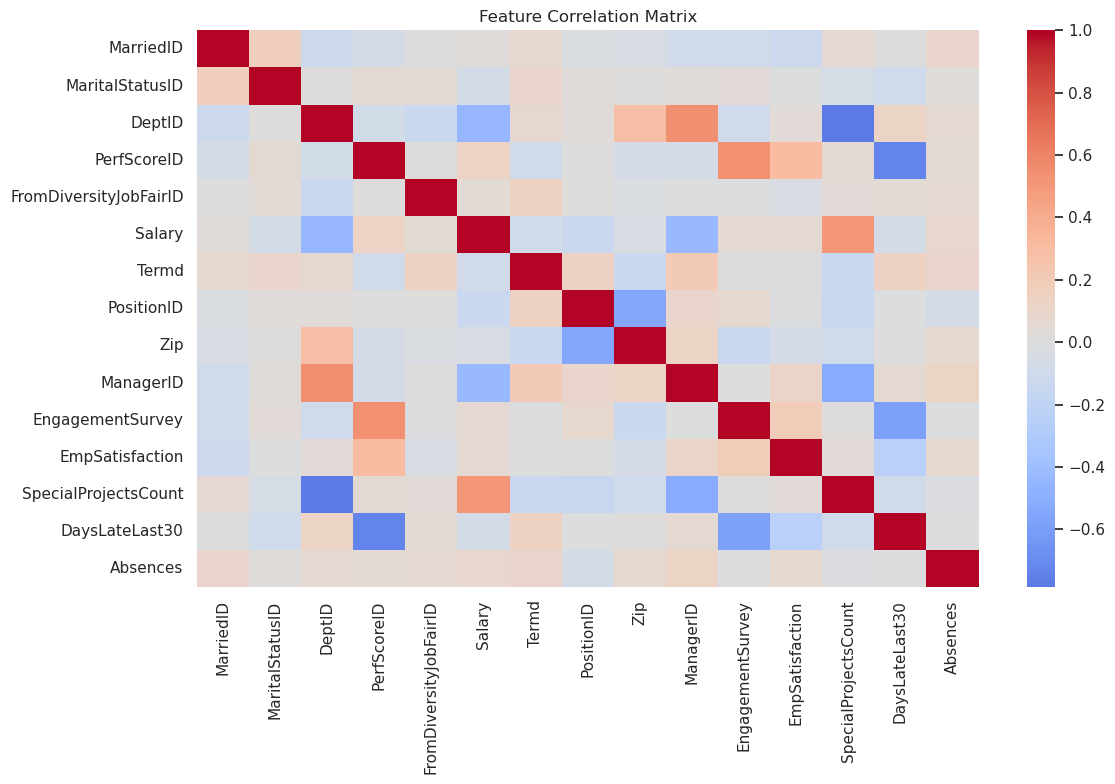

In [12]:
print("First 5 rows of the cleaned DataFrame:")
print(df_clean.head())

print("\n DataFrame info:")
df_clean.info()

print("\n Descriptive statistics of numerical columns:")
print(df_clean.describe())

print("\n Number of unique values per column:")
print(df_clean.nunique())

# Calculate correlation matrix (only for numeric columns)
corr_matrix = df_clean.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

Top departure reasons:
TermReason
Another position          20
unhappy                   14
more money                11
career change              9
hours                      8
attendance                 7
return to school           5
relocation out of area     5
performance                4
military                   4
Name: count, dtype: int64


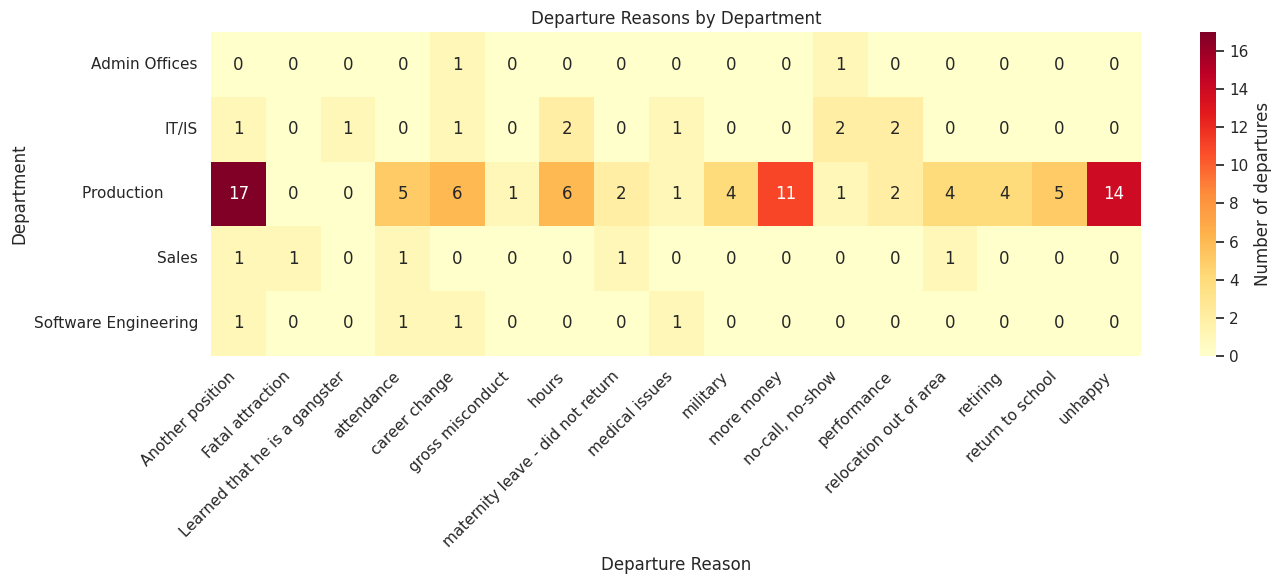

In [ ]:
# Top reasons for departure
df_departed = df[df['Termd'] == 1]
top_reasons = df_departed['TermReason'].value_counts().head(10)

print('Top departure reasons:')
print(top_reasons)

# Heatmap to determine which departments have the most departures and for what reason
df_cross = pd.crosstab(df_departed['Department'], df_departed['TermReason'])

plt.figure(figsize=(14, 6))
sns.heatmap(df_cross, annot=True, cmap='YlOrRd', fmt='d', cbar_kws={'label': 'Number of departures'})
plt.title('Departure Reasons by Department')
plt.xlabel('Departure Reason')
plt.ylabel('Department')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

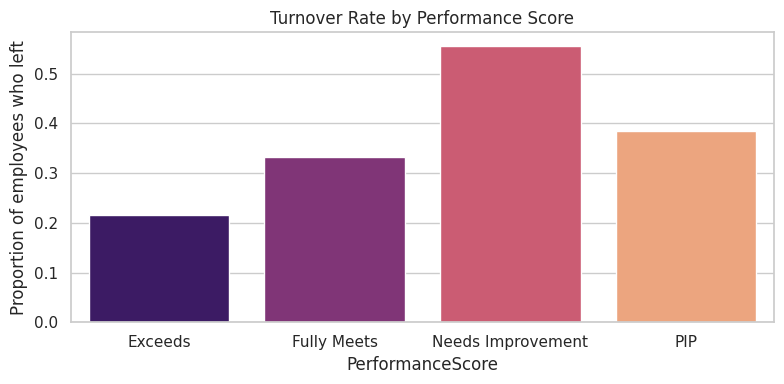

In [ ]:
# Does performance score influence turnover?
perf_turnover = df.groupby('PerformanceScore')['Termd'].mean().reset_index()
perf_turnover.rename(columns={'Termd': 'Turnover Rate'}, inplace=True)

plt.figure(figsize=(8, 4))
sns.barplot(data=perf_turnover, x='PerformanceScore', y='Turnover Rate', palette='magma')
plt.title('Turnover Rate by Performance Score')
plt.ylabel('Proportion of employees who left')
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

In [ ]:
# Fill missing values
print(f'Missing values before: {df_clean.isnull().sum().sum()}')
df_clean = df_clean.ffill()
print(f'Missing values after:  {df_clean.isnull().sum().sum()}')

# Encode text columns into numbers
label_encoders = {}
for col in df_clean.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le

# Split features and target
X = df_clean.drop('Termd', axis=1)
y = df_clean['Termd']

# Train / test split (stratify keeps the class ratio the same in both sets)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples')
print(f'Class balance: {y.mean():.1%} left, {1 - y.mean():.1%} stayed')

Missing values before: 8
Missing values after:  0
Train: 248 samples, Test: 63 samples
Class balance: 33.4% left, 66.6% stayed


## 4. Frugal AI : Carbon-Tracked Model Training

We use CodeCarbon to measure the carbon footprint of our training.
We also keep the model deliberately simple (shallow Random Forest) instead of using a heavier model.
Frugal AI means: use the simplest model that solves the problem.

In [ ]:
# Start tracking carbon emissions
if CODECARBON_AVAILABLE:
    tracker = EmissionsTracker(project_name='HR-Turnover', log_level='error')
    tracker.start()

# Train a shallow Random Forest (frugal choice: max_depth=5, 100 trees)
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)

# Stop tracker and print the result
if CODECARBON_AVAILABLE:
    emissions = tracker.stop()
    print(f'Carbon footprint of training: {emissions * 1000:.6f} gCO2eq')
else:
    print('Carbon tracking not available (CodeCarbon not installed).')

print('Model trained.')

Carbon footprint of training: 0.001504 gCO2eq
Model trained.


AUC-ROC: 0.924

              precision    recall  f1-score   support

      Stayed       0.86      1.00      0.92        42
        Left       1.00      0.67      0.80        21

    accuracy                           0.89        63
   macro avg       0.93      0.83      0.86        63
weighted avg       0.90      0.89      0.88        63



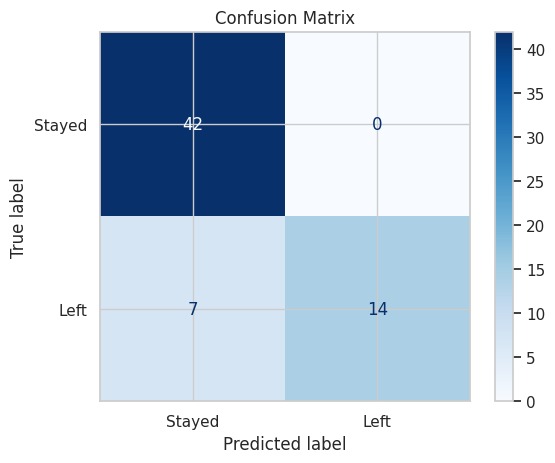

In [ ]:
# Evaluate the model
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)
print(f'AUC-ROC: {auc:.3f}')
print()
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Left']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Left']).plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

## 5. Explainable AI : SHAP

HR managers need to understand why the model flags an employee as at risk.
We use SHAP to explain predictions at two levels:
- **Global**: which features matter most across all employees?
- **Individual**: why did the model predict this specific employee would leave?

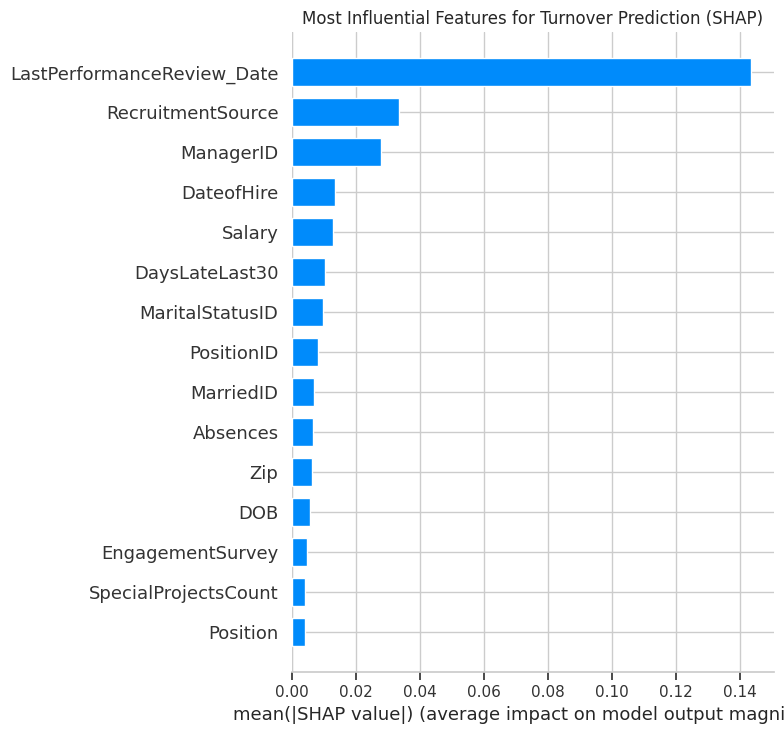

In [ ]:
# Compute SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Handle different SHAP output formats depending on the version
if isinstance(shap_values, list):
    shap_vals_target = shap_values[1]
elif len(np.shape(shap_values)) == 3:
    shap_vals_target = shap_values[:, :, 1]
else:
    shap_vals_target = shap_values

# Global view: which features drive turnover the most?
shap.summary_plot(shap_vals_target, X_test, plot_type='bar', show=False, max_display=15)
plt.title('Most Influential Features for Turnover Prediction (SHAP)')
plt.tight_layout()
plt.show()

Highest risk employee (test index 280)
Predicted probability of leaving: 88.8%
Actual outcome: Left


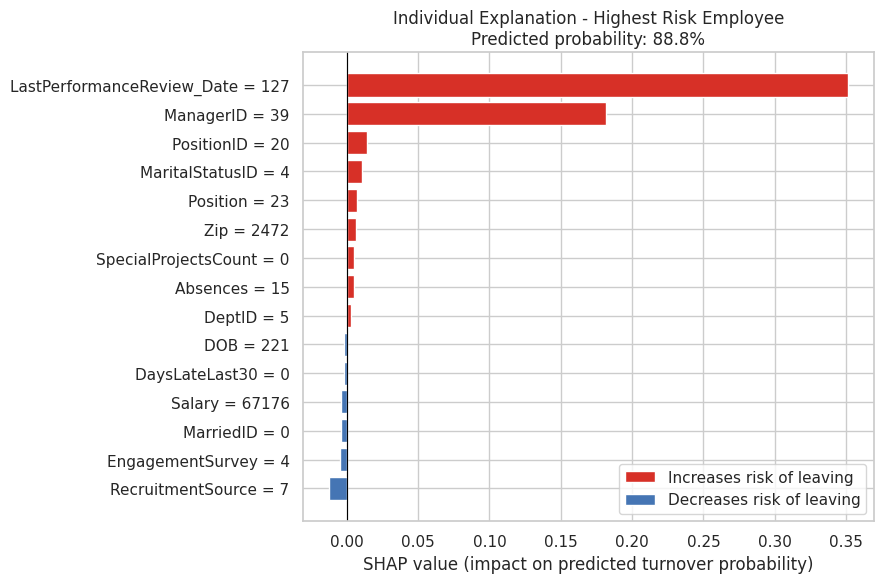

In [ ]:
# Individual explanation: focus on the highest-risk employee
highest_risk_idx = np.argmax(y_prob)
print(f'Highest risk employee (test index {X_test.index[highest_risk_idx]})')
print(f'Predicted probability of leaving: {y_prob[highest_risk_idx]:.1%}')
print(f'Actual outcome: {"Left" if y_test.iloc[highest_risk_idx] == 1 else "Stayed"}')

# Build a bar chart of SHAP values for this employee
shap_row = shap_vals_target[highest_risk_idx, :]
shap_df = pd.DataFrame({
    'feature': X_test.columns,
    'shap_value': shap_row,
    'feature_value': X_test.iloc[highest_risk_idx].values
})

# Keep only the top 15 most impactful features
shap_df['abs_shap'] = shap_df['shap_value'].abs()
shap_df = shap_df.nlargest(15, 'abs_shap').sort_values('shap_value')

# Color bars: red = pushes toward leaving, blue = pushes toward staying
colors = ['#d73027' if v > 0 else '#4575b4' for v in shap_df['shap_value']]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(
    [f"{row['feature']} = {row['feature_value']:.0f}" for _, row in shap_df.iterrows()],
    shap_df['shap_value'],
    color=colors,
    edgecolor='white'
)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('SHAP value (impact on predicted turnover probability)')
ax.set_title(
    f'Individual Explanation - Highest Risk Employee\n'
    f'Predicted probability: {y_prob[highest_risk_idx]:.1%}',
    fontsize=12
)

# Add a small legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#d73027', label='Increases risk of leaving'),
                   Patch(facecolor='#4575b4', label='Decreases risk of leaving')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

## 6. Ethical AI : Bias Audit

Even though we removed gender and ethnicity from training, the model might still have learned biased patterns from other features.
We check whether the predicted turnover rates are similar across demographic groups.
A large difference would indicate the model is not fair.

In [ ]:
# Build the audit dataframe by adding sensitive attributes back
df_audit = pd.DataFrame({
    'True_Label': y_test.values,
    'Predicted_Label': y_pred,
    'Risk_Score': y_prob,
    'Gender': sensitive_data.loc[X_test.index, 'Sex'].values,
    'Ethnicity': sensitive_data.loc[X_test.index, 'RaceDesc'].values
})

# Predicted turnover rate by gender
gender_bias = df_audit.groupby('Gender')['Predicted_Label'].mean().reset_index()
gender_bias.rename(columns={'Predicted_Label': 'Predicted Turnover Rate'}, inplace=True)

print('Bias audit by gender:')
print(gender_bias)

# Predicted turnover rate by ethnicity
ethnicity_bias = df_audit.groupby('Ethnicity')['Predicted_Label'].mean().reset_index()
ethnicity_bias.rename(columns={'Predicted_Label': 'Predicted Turnover Rate'}, inplace=True)

print('\nBias audit by ethnicity:')
print(ethnicity_bias)

Bias audit by gender:
  Gender  Predicted Turnover Rate
0      F                 0.235294
1     M                  0.206897

Bias audit by ethnicity:
                          Ethnicity  Predicted Turnover Rate
0  American Indian or Alaska Native                 0.000000
1                             Asian                 0.142857
2         Black or African American                 0.200000
3                 Two or more races                 0.333333
4                             White                 0.250000


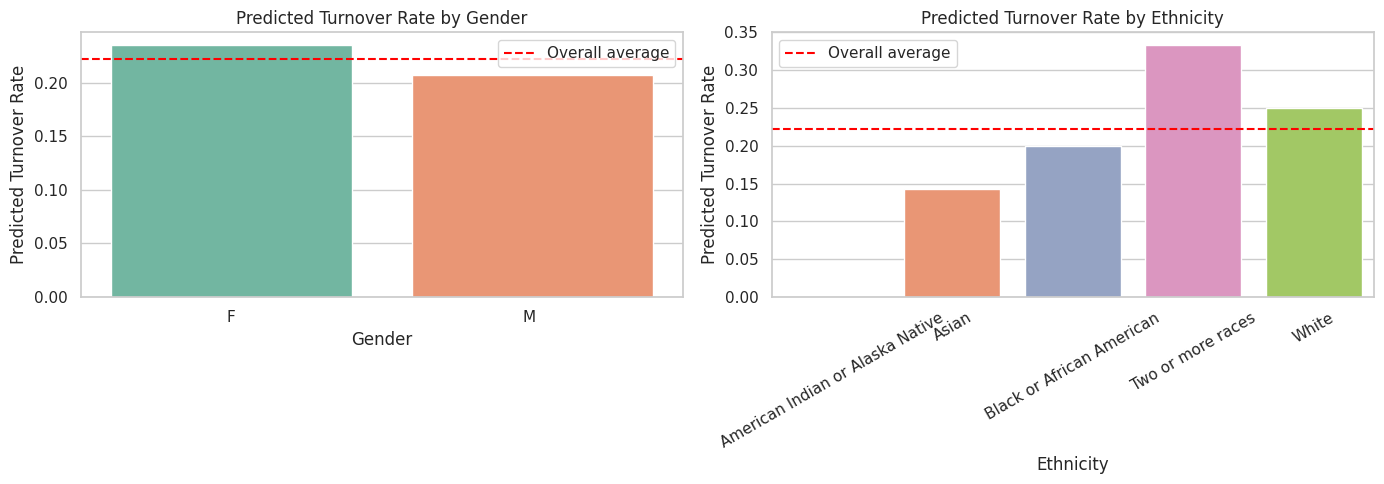

Gender disparity: 2.8%
Disparity below 5%, model seems fair on gender.


In [ ]:
# Visualize the bias
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=gender_bias, x='Gender', y='Predicted Turnover Rate', ax=axes[0], palette='Set2')
axes[0].axhline(df_audit['Predicted_Label'].mean(), color='red', linestyle='--', label='Overall average')
axes[0].set_title('Predicted Turnover Rate by Gender')
axes[0].set_ylabel('Predicted Turnover Rate')
axes[0].legend()

sns.barplot(data=ethnicity_bias, x='Ethnicity', y='Predicted Turnover Rate', ax=axes[1], palette='Set2')
axes[1].axhline(df_audit['Predicted_Label'].mean(), color='red', linestyle='--', label='Overall average')
axes[1].set_title('Predicted Turnover Rate by Ethnicity')
axes[1].set_ylabel('Predicted Turnover Rate')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

plt.tight_layout()
plt.show()

# Check if the disparity between groups too large
disparity = gender_bias['Predicted Turnover Rate'].max() - gender_bias['Predicted Turnover Rate'].min()
print(f'Gender disparity: {disparity:.1%}')
if disparity < 0.05:
    print('Disparity below 5%, model seems fair on gender.')
else:
    print('Disparity above 5%, potential bias detected, investigate further.')

In [ ]:
!pip install -q gradio

In [ ]:
import gradio as gr
import pandas as pd
import numpy as np
import shap

# 1. SHAP CALCULATIONS & PREDICTIONS
y_prob_all = model.predict_proba(X)[:, 1]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

if isinstance(shap_values, list):
    shap_vals = shap_values[1]
elif len(np.shape(shap_values)) == 3:
    shap_vals = shap_values[:, :, 1]
else:
    shap_vals = shap_values

# 2. BUILD ENRICHED DATASET
df_dash = pd.DataFrame({
    'name':     df.loc[X.index, 'Employee_Name'].values,
    'dept':     df.loc[X.index, 'Department'].values,
    'pos':      df.loc[X.index, 'Position'].values,
    'status':   df.loc[X.index, 'EmploymentStatus'].values,
    'risk':     np.round(y_prob_all, 4),
    'salary':   df.loc[X.index, 'Salary'].values,
    'sat':      df.loc[X.index, 'EmpSatisfaction'].values,
    'eng':      df.loc[X.index, 'EngagementSurvey'].values,
    'abs':      df.loc[X.index, 'Absences'].values,
    'late':     df.loc[X.index, 'DaysLateLast30'].values,
    'perf':     df.loc[X.index, 'PerformanceScore'].values,
    'projects': df.loc[X.index, 'SpecialProjectsCount'].values,
    'tenure':   pd.to_datetime('today').year - pd.to_datetime(df.loc[X.index, 'DateofHire']).dt.year.values,
}).reset_index(drop=True)

FEATURE_LABELS = {
    'EmpSatisfaction': 'Low satisfaction', 'EngagementSurvey': 'Low engagement',
    'Absences': 'High absenteeism', 'DaysLateLast30': 'Frequent lateness',
    'PerfScoreID': 'Low performance', 'Salary': 'Below market salary',
    'SpecialProjectsCount': 'Lack of projects', 'ManagerID': 'Manager relationship'
}

# SHAP-based approach: create a dataframe with top features
def get_reasons(idx):
    shap_row = shap_vals[idx]

    # Create SHAP dataframe
    shap_df = pd.DataFrame({
        'feature': X.columns,
        'shap_value': shap_row,
        'feature_value': X.iloc[idx].values
    })

    # Keep top 15 most impactful features
    shap_df['abs_shap'] = shap_df['shap_value'].abs()
    shap_df = shap_df.nlargest(15, 'abs_shap').sort_values('shap_value', ascending=False)

    # Keep only positive values (increase risk)
    shap_df = shap_df[shap_df['shap_value'] > 0]

    reasons = []
    for _, row in shap_df.iterrows():
        if len(reasons) >= 4:
            break
        label = FEATURE_LABELS.get(row['feature'], row['feature'])
        # Normalize percentage based on SHAP magnitude
        pct = int(min(abs(row['shap_value']) * 400, 95))
        if pct > 0:
            reasons.append({'label': label, 'pct': pct})

    return reasons if reasons else [{'label': 'Stable profile', 'pct': 10}]

df_dash['reasons'] = [get_reasons(i) for i in range(len(df_dash))]

# Build recommended actions based on employee data
def build_actions(row):
    actions = []
    if row['sat'] <= 2: actions.append({'color': '#ef4444', 'bg': '#fef2f2', 'title': 'Urgent 1-on-1 meeting', 'desc': "Schedule a meeting to understand dissatisfaction."})
    if row['eng'] <= 2.5: actions.append({'color': '#ef4444', 'bg': '#fef2f2', 'title': 'Redefine objectives', 'desc': "Restore meaning in current tasks."})
    if row['salary'] < 62000: actions.append({'color': '#f59e0b', 'bg': '#fffbeb', 'title': 'Salary review', 'desc': "Analyze market positioning."})
    if row['abs'] >= 13: actions.append({'color': '#f59e0b', 'bg': '#fffbeb', 'title': 'Well-being follow-up', 'desc': "Check work-life balance."})
    if not actions: actions.append({'color': '#10b981', 'bg': '#ecfdf5', 'title': 'Maintain engagement', 'desc': "Continue standard management routines."})
    return actions[:3]

df_dash['actions'] = df_dash.apply(build_actions, axis=1)

# 3. GRADIO LOGIC
def filter_dashboard(dept, min_risk):
    filtered = df_dash.copy()
    if dept != "Tous":
        filtered = filtered[filtered['dept'] == dept]
    filtered = filtered[filtered['risk'] >= (min_risk / 100.0)]
    filtered = filtered.sort_values(by='risk', ascending=False).reset_index(drop=True)

    total_emp = len(filtered)
    avg_risk = f"{(filtered['risk'].mean() * 100):.0f}%" if total_emp > 0 else "0%"

    table_view = pd.DataFrame({
        'Employee': filtered['name'],
        'Position': filtered['pos'],
        'Status': filtered['status'],
        'Risk Score': (filtered['risk'] * 100).round(0).astype(int).astype(str) + "%",
        'Main Reason': [r[0]['label'] if len(r)>0 else "N/A" for r in filtered['reasons']]
    })

    # Default placeholder when no employee is selected
    default_html = """
    <div style='padding: 50px 20px; color: #64748b; text-align: center; font-family: "Segoe UI", sans-serif; background: linear-gradient(to bottom right, #f8fafc, #f1f5f9); border-radius: 16px; border: 2px dashed #cbd5e1; margin-top: 15px;'>
        <div style="font-size: 2rem; margin-bottom: 10px;"></div>
        <h3 style="margin: 0; color: #475569;">Select an employee</h3>
        <p style="margin-top: 5px; font-size: 0.9rem;">Click on a row in the table to analyze risk factors in detail.</p>
    </div>
    """

    return total_emp, avg_risk, table_view, filtered, default_html

# Display detailed employee analysis
def show_details(evt: gr.SelectData, filtered_data):
    row_idx = evt.index[0]
    if row_idx >= len(filtered_data):
        return ""

    emp = filtered_data.iloc[row_idx]

    # Dynamic styles for bars (gradients)
    def get_gradient(pct):
        if pct >= 70: return "linear-gradient(90deg, #fca5a5, #ef4444)"
        if pct >= 40: return "linear-gradient(90deg, #fcd34d, #f59e0b)"
        return "linear-gradient(90deg, #6ee7b7, #10b981)"

    def get_text_color(pct):
        if pct >= 70: return "#dc2626"
        if pct >= 40: return "#d97706"
        return "#059669"

    # Risk factors HTML
    reasons_html = ""
    for r in emp['reasons']:
        grad = get_gradient(r['pct'])
        txt_col = get_text_color(r['pct'])
        reasons_html += f"""
        <div style="margin-bottom: 18px;">
            <div style="display: flex; justify-content: space-between; font-size: 0.9rem; color: #334155; font-weight: 600; margin-bottom: 8px;">
                <span style="color: #334155">{r['label']}</span>
                <span style="color: {txt_col}; font-weight: 700;">{r['pct']}%</span>
            </div>
            <div style="width: 100%; height: 10px; background: #e2e8f0; border-radius: 10px; overflow: hidden; box-shadow: inset 0 1px 2px rgba(0,0,0,0.05);">
                <div style="width: {r['pct']}%; height: 100%; background: {grad}; border-radius: 10px;"></div>
            </div>
        </div>
        """

    # Actions HTML
    actions_html = ""
    for a in emp['actions']:
        actions_html += f"""
        <div style="background: {a['bg']}; border-radius: 10px; padding: 16px; margin-bottom: 14px; border-left: 5px solid {a['color']}; box-shadow: 0 2px 4px rgba(0,0,0,0.02); transition: transform 0.2s;">
            <div style="font-size: 0.95rem; font-weight: 700; color: #1e293b; margin-bottom: 6px; display: flex; align-items: center; gap: 8px;">
                <span style="display: inline-block; width: 10px; height: 10px; border-radius: 50%; background: {a['color']}; box-shadow: 0 0 0 3px #ffffff;"></span>
                {a['title']}
            </div>
            <p style="font-size: 0.85rem; color: #475569; margin: 0; line-height: 1.5; padding-left: 18px;">{a['desc']}</p>
        </div>
        """

    # Status badge colors
    is_active = emp['status'].lower() == 'active'
    status_bg = "#dcfce7" if is_active else "#f1f5f9"
    status_txt = "#166534" if is_active else "#475569"

    # Final card rendering
    html_out = f"""
    <div style="font-family: 'Segoe UI', system-ui, sans-serif; background: #ffffff; border-radius: 20px; box-shadow: 0 10px 30px -5px rgba(0,0,0,0.1); border: 1px solid #e2e8f0; padding: 32px; display: flex; flex-wrap: wrap; gap: 40px; margin-top: 15px;">

        <div style="flex: 1; min-width: 300px;">
            <div style="margin-bottom: 25px; border-bottom: 2px solid #f8fafc; padding-bottom: 15px; display: flex; justify-content: space-between; align-items: center;">
                <h3 style="margin: 0; color: #0f172a; font-size: 1.25rem;">Risk Profile</h3>
                <span style="background: {status_bg}; color: {status_txt}; padding: 6px 14px; border-radius: 20px; font-weight: 700; font-size: 0.8rem; letter-spacing: 0.5px;">
                    {emp['name']} • {emp['status']}
                </span>
            </div>
            {reasons_html}
        </div>

        <div style="flex: 1; min-width: 300px;">
            <div style="margin-bottom: 25px; border-bottom: 2px solid #f8fafc; padding-bottom: 15px;">
                <h3 style="margin: 0; color: #0f172a; font-size: 1.25rem;">Recommended Action Plan</h3>
            </div>
            {actions_html}
        </div>

    </div>
    """
    return html_out

# 4. GRADIO UI
custom_theme = gr.themes.Soft(
    primary_hue="indigo",
    neutral_hue="slate",
    font=[gr.themes.GoogleFont("Inter"), "ui-sans-serif", "system-ui", "sans-serif"]
)

with gr.Blocks(theme=custom_theme) as demo:
    gr.Markdown("""
    # Analytical HR Dashboard
    Employee attrition risk prediction powered by a Machine Learning model.
    """)

    filtered_state = gr.State()

    with gr.Row(variant="panel"):
        with gr.Column(scale=2):
            with gr.Row():
                dept_dropdown = gr.Dropdown(
                    choices=["Tous"] + list(df_dash['dept'].unique()),
                    value="Tous",
                    label="Filter by Department"
                )
                risk_slider = gr.Slider(
                    minimum=0, maximum=90, step=5, value=0,
                    label="Minimum Risk (%)"
                )
        with gr.Column(scale=1):
            kpi_total = gr.Textbox(label="Employees Displayed", interactive=False)
        with gr.Column(scale=1):
            kpi_avg = gr.Textbox(label="Average Risk", interactive=False)

    emp_table = gr.Dataframe(
        headers=["Employee", "Position", "Status", "Risk Score", "Main Reason"],
        interactive=False,
        type="pandas",
        row_count=(5, "dynamic")
    )

    detail_panel = gr.HTML()

    inputs_filters = [dept_dropdown, risk_slider]
    outputs_filters = [kpi_total, kpi_avg, emp_table, filtered_state, detail_panel]

    dept_dropdown.change(filter_dashboard, inputs_filters, outputs_filters)
    risk_slider.change(filter_dashboard, inputs_filters, outputs_filters)

    emp_table.select(show_details, filtered_state, detail_panel)

    demo.load(filter_dashboard, inputs_filters, outputs_filters)

demo.launch(inline=True, share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://47b8e4c37b79b1cd9b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
